
<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'> CROSS VAL -  RSCV GSCV FOR Random Forest </h2>
</div>

<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

# HERE CLASSIFICATION PROB USED, SO TO CHANGE THE CODE FOR REGRESSION AND COPY THIS FILE TO BASIC FOLDER

## Module 14 Case study 1 - Cross val and Boosting

## Case Study

### Objectives:
    •Learn to use Cross validation to pick the best models.
    
- Questions:
  - 1.Load the data from “glass.csv” and make a bar plot of different types of glasses.
  - 2.Make a train_test split and fit a single decision tree classifier.
  - 3.Make a k-fold split with 3 splits and measure the accuracy score with each split
    [Hint:Refer to KFold module under sklearn’s model selection.]
  - 4.Use gridSearchCV from sklearn for finding out a suitable number of estimators for a Random ForestClassifer alongwith a 10-fold cross validation.
    [Hint:Define a range of estimators and feed in range as param_grid]


##  1. Import all Librariy

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn



from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics

In [23]:
#Read data
df = pd.read_csv (r'..\Dataset\glass.csv'
                 )

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 2. Data Exploration

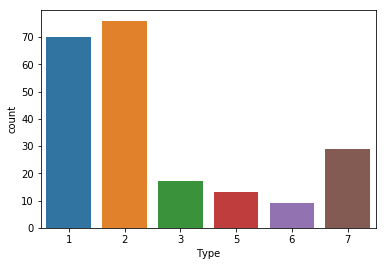

In [24]:
#bar plot of different types of glasses.
sn.countplot(df.Type)

* There are 7 types of plots, 2nd type has more count

## 3. Building Machine Learning KMean Cluster

In [25]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, random_state=5)
train.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
153,1.51610,13.42,3.40,1.22,72.69,0.59,8.32,0.00,0.00,3
50,1.52320,13.72,3.72,0.51,71.75,0.09,10.06,0.00,0.16,1
213,1.51711,14.23,0.00,2.08,73.36,0.00,8.62,1.67,0.00,7
120,1.51844,13.25,3.76,1.32,72.40,0.58,8.42,0.00,0.00,2
23,1.51751,12.81,3.57,1.35,73.02,0.62,8.59,0.00,0.00,1


In [26]:
train_X = train.iloc[:,:-1]
train_Y = train.iloc[:,-1]
test_X = test.iloc[:,0:-1]
test_Y = test.iloc[:,-1]
train_X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
153,1.51610,13.42,3.40,1.22,72.69,0.59,8.32,0.00,0.00
50,1.52320,13.72,3.72,0.51,71.75,0.09,10.06,0.00,0.16
213,1.51711,14.23,0.00,2.08,73.36,0.00,8.62,1.67,0.00
120,1.51844,13.25,3.76,1.32,72.40,0.58,8.42,0.00,0.00
23,1.51751,12.81,3.57,1.35,73.02,0.62,8.59,0.00,0.00


### 3.1 Make a train_test split and fit a single decision tree classifier.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [28]:
model = DecisionTreeClassifier()
model.fit(train_X, train_Y)
prediction_op = model.predict(test_X)

accuracy =  metrics.accuracy_score(test_Y, prediction_op)
accuracy

0.7592592592592593

In [29]:
# Confusion matrix for classification
from sklearn.metrics import confusion_matrix
confusion_matrix(test_Y, prediction_op)

array([[16,  2,  1,  0,  0,  2],
       [ 1, 14,  1,  1,  0,  0],
       [ 1,  2,  1,  0,  0,  0],
       [ 0,  0,  0,  1,  0,  0],
       [ 0,  1,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  1,  8]], dtype=int64)

### 3.2 Make a k-fold split with 3 splits and measure the accuracy score with each split
- [Hint:Refer to KFold module under sklearn’s model selection.]

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

#KFold Module
kfold = KFold(n_splits=3, random_state=5)

## Apply Cross validation on knn model, with k-fold/cv=3, and take mean which is the avg of all 10 accuracy
print("Accuracy score in each split :\n", cross_val_score(model, train_X,train_Y, cv=kfold, scoring ='accuracy'))#.mean())

Accuracy score in each split :
 [0.72222222 0.50943396 0.64150943]


## 4. Use GRIDSearchCV  or RANDOMSearchCV   from sklearn for finding out a suitable number of estimators for a Random ForestClassifer alongwith a 10-fold cross validation. 
- [Hint:Define a range of estimators and feed in range as param_grid]

### 4.1 Method 1 with RandomizedSearchCV

##### Here we are setting param value of random forest with grid search and then using kflod =10 approach to see the accuracy of model

In [31]:
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier

RF_reg = RandomForestClassifier(random_state=42)

In [32]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(RF_reg.get_params())

Parameters currently in use:

{'bootstrap': True,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 'warn',
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [33]:
param_grid = { 
    'n_estimators': [200, 500],  # No of tree in forest
    'max_features': ['auto', 'sqrt', 'log2'],  #max number of features considered for splitting a node
    'max_depth' : [4,5,6,7,8],  # max number of levels in each decision tree
    'criterion' :['gini', 'entropy']
}

#Total candidates = 2*3*5*2=60  (its no of items in above all values)
#On each iteration, the algorithm will choose a difference combination of the features.

In [34]:
#from sklearn.model_selection import GridSearchCV
#grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 3, n_jobs = -1, verbose = 2)

                            
from sklearn.model_selection import RandomizedSearchCV
# Random search of parameters, using 10 fold cross validation
CV_rfc = RandomizedSearchCV(estimator=RF_reg, param_distributions =param_grid, cv= 10 ,n_iter = 100,verbose=2,
                            random_state=42, n_jobs = -1)
CV_rfc.fit(train_X, train_Y)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:271: UserWarning: The total space of parameters 60 is smaller than n_iter=100. Running 60 iterations. For exhaustive searches, use GridSearchCV.
  % (grid_size, self.n_iter, grid_size), UserWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 7 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Fitting 10 folds for each of 60 candidates, totalling 600 fits


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:   34.0s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:   57.6s finished
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


RandomizedSearchCV(cv=10, error_score='raise-deprecating',
          estimator=RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=42, verbose=0, warm_start=False),
          fit_params=None, iid='warn', n_iter=100, n_jobs=-1,
          param_distributions={'n_estimators': [200, 500], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [4, 5, 6, 7, 8], 'criterion': ['gini', 'entropy']},
          pre_dispatch='2*n_jobs', random_state=42, refit=True,
          return_train_score='warn', scoring=None, verbose=2)

#### 4.1 The most important arguments in RandomizedSearchCV are 
- n_iter, which controls the number of different combinations to try, and 
- cv which is the number of folds to use for cross validation (we use 10 here). 
- More iterations will cover a wider search space and more cv folds reduces the chances of overfitting, but raising each will increase the run time. 
- Machine learning is a field of trade-offs, and performance vs time is one of the most fundamental.


In [40]:
# We can view the best parameters from fitting the random search:
CV_rfc.best_params_

{'n_estimators': 200,
 'max_features': 'auto',
 'max_depth': 7,
 'criterion': 'entropy'}

** From these results, we should be able to narrow the range of values for each hyperparameter.

#### 4.2 Evaluate Random Search

In [41]:
print(CV_rfc.best_estimator_)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=7, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=200, n_jobs=None,
            oob_score=False, random_state=42, verbose=0, warm_start=False)


In [42]:
def evaluate(model, test_X, test_Y):
    predictions = model.predict(test_X)
    errors = abs(predictions - test_Y)
    mape = 100 * np.mean(errors / test_Y)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(accuracy))
    print('\n')
    return accuracy

#Old RF model 
base_model = RandomForestClassifier(n_estimators = 10, random_state = 42)
base_model.fit(train_X, train_Y)

# Call evaluate func passing test dataset
base_accuracy = evaluate(base_model, test_X, test_Y)

#New randomgrid applied RF with its best estimator, best_estimator_ gives RF model all feature
best_random = CV_rfc.best_estimator_

random_accuracy = evaluate(best_random, test_X, test_Y)

print('Improvement of {:0.2f}%.'.format( 100 * (random_accuracy - base_accuracy) / base_accuracy))

Model Performance
Average Error: 0.4815 degrees.
Accuracy = 68.87%.


Model Performance
Average Error: 0.3704 degrees.
Accuracy = 85.10%.


Improvement of 23.56%.


### 4.2 Method 2  - with GridSearchCV

In [1]:
"""
# RANDOM SEARCH CV

RF_reg = RandomForestClassifier(random_state=42)

from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(RF_reg.get_params())

##Set parameter


param_grid = { 
    'n_estimators': [200, 500],  # No of tree in forest
    'max_features': ['auto', 'sqrt', 'log2'],  #max number of features considered for splitting a node
    'max_depth' : [4,5,6,7,8],  # max number of levels in each decision tree
    'criterion' :['gini', 'entropy']
}


# Random search of parameters, using 10 fold cross validation


CV_rfc = RandomizedSearchCV(estimator=RF_reg, param_distributions =param_grid, cv= 10 ,n_iter = 100,verbose=2, random_state=42, n_jobs = -1)
CV_rfc.fit(train_X, train_Y)


# We can view the best parameters from fitting the random search:
CV_rfc.best_params_



#Evaluate the model:
def evaluate(model, test_X, test_Y):
    predictions = model.predict(test_X)
    errors = abs(predictions - test_Y)
    mape = 100 * np.mean(errors / test_Y)
    accuracy = 100 - mape
    print('Model Performance')
    print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(accuracy))
    print('\n')
    return accuracy


#Old RF model 



base_model = RandomForestClassifier(n_estimators = 10, random_state = 42)
base_model.fit(train_X, train_Y)
# Call evaluate func passing test dataset
base_accuracy = evaluate(base_model, test_X, test_Y)


#New randomgrid applied RF with its best estimator, best_estimator_ gives RF model all feature


best_random = CV_rfc.best_estimator_
random_accuracy = evaluate(best_random, test_X, test_Y)

print('Improvement of {:0.2f}%.'.format( 100 * (random_accuracy - base_accuracy) / base_accuracy))


"""

"\n# RANDOM SEARCH CV\n\nRF_reg = RandomForestClassifier(random_state=42)\n\nfrom pprint import pprint\n# Look at parameters used by our current forest\nprint('Parameters currently in use:\n')\npprint(RF_reg.get_params())\n\n##Set parameter\n\n\nparam_grid = { \n    'n_estimators': [200, 500],  # No of tree in forest\n    'max_features': ['auto', 'sqrt', 'log2'],  #max number of features considered for splitting a node\n    'max_depth' : [4,5,6,7,8],  # max number of levels in each decision tree\n    'criterion' :['gini', 'entropy']\n}\n\n\n# Random search of parameters, using 10 fold cross validation\n\n\nCV_rfc = RandomizedSearchCV(estimator=RF_reg, param_distributions =param_grid, cv= 10 ,n_iter = 100,verbose=2, random_state=42, n_jobs = -1)\nCV_rfc.fit(train_X, train_Y)\n\n\n# We can view the best parameters from fitting the random search:\nCV_rfc.best_params_\n\n\n\n#Evaluate the model:\ndef evaluate(model, test_X, test_Y):\n    predictions = model.predict(test_X)\n    errors = ab

In [43]:
from sklearn.model_selection import GridSearchCV

# Create the parameter grid based on the results of random search 
param_grid = {
    'bootstrap': [True],
    'max_depth': [80, 90, 100, 110],
    'max_features': ['auto', 'sqrt'],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [8, 10, 12],
    'n_estimators': [100, 200, 300, 1000]
}

"""
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]

max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]

max_features = ['auto', 'sqrt']

min_samples_split = [2, 5, 10]

min_samples_leaf = [1, 2, 4]
"""

In [44]:
# Create a based model
rf = RandomForestClassifier()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator = rf, param_grid = param_grid, cv = 10, n_jobs = -1, verbose = 2)


* This will try out 1 * 4 * 2 * 3 * 3 * 4 = 288 combinations of settings. We can fit the model, display the best hyperparameters, and evaluate performance:


###  Fit the grid search to the data


In [45]:
grid_search.fit(train_X, train_Y)

grid_search.best_params_


Fitting 10 folds for each of 288 candidates, totalling 2880 fits


C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:652: Warning: The least populated class in y has only 7 members, which is too few. The minimum number of members in any class cannot be less than n_splits=10.
  % (min_groups, self.n_splits)), Warning)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   11.3s
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 997 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 1969 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 2576 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done 2880 out of 2880 | elapsed:  5.9min finished
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\model_selection\_searc

{'bootstrap': True,
 'max_depth': 80,
 'max_features': 3,
 'min_samples_leaf': 3,
 'min_samples_split': 8,
 'n_estimators': 100}

In [46]:
best_grid = grid_search.best_estimator_
grid_accuracy = evaluate(best_grid, test_X, test_Y)


Model Performance
Average Error: 0.2963 degrees.
Accuracy = 86.16%.




In [47]:
print('Improvement of {:0.2f}%.'.format( 100 * (grid_accuracy - base_accuracy) / base_accuracy))


Improvement of 25.10%.


## 5. Conclusion:

### Method 1 "Improvement of 18.18%." and Method 2 with "Improvement of 23.56%." compared to direct RF (without any parameter search and CV)

### Method 1: Model Performance
- Average Error: 0.4074 degrees
- Accuracy = 81.39%.


### Method 2: Model Performance
- Average Error: 0.3704 degrees.
- Accuracy = 85.10%.

### Base Model without any parameter search and CV : Model Performance
- Average Error: 0.4815 degrees.
- Accuracy = 68.87%.